# Anomaly Detection in Credit Card Transaction Data

This notebook treats fraud labels as unavailable during training and uses them only for evaluation. The goal is not to maximize a leaderboard metric; it is to design a practical anomaly scoring system that reduces analyst review burden while failing safely for a high-risk financial workflow.

### Install dependencies

This installs the compatible package versions defined in `requirements.txt`.

In [1]:
# optional colab initialization 
# 1. Clear out old files and clone the updated repository

# %cd /content
# !rm -rf ML-ENGINEER-TAKE-HOME
# !git clone https://github.com/DrEaston/ML-ENGINEER-TAKE-HOME.git
# %cd ML-ENGINEER-TAKE-HOME

In [2]:
%pip install --quiet --disable-pip-version-check -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## 1. Exploration and framing

Operational framing:

- The current rule system flags about 5% of transactions.
- Analysts estimate roughly 90% of flagged transactions are false positives.
- Missing fraud is more dangerous than reviewing extra false positives.
- I therefore choose a default operating point based on review capacity: flag the top 5% highest-risk transactions and evaluate whether the model captures more fraud at the same review burden.

I also evaluate lower and higher review rates to show the precision/recall tradeoff.

### Load the data and scoring code

This cell imports the reusable scoring and evaluation interfaces from `fraud_scoring.py`, downloads the public dataset through KaggleHub, and previews the first rows. It also fixes the random seed so later sampling and model fitting are reproducible.

In [3]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from fraud_scoring import (
    FEATURE_COLUMNS,
    FraudAnomalyScorer,
    evaluate_at_review_rate,
    train_anomaly_scorer,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Always acquire the public dataset through KaggleHub.
import kagglehub

dataset_dir = Path(kagglehub.dataset_download("mlg-ulb/creditcardfraud"))
DATA_PATH = dataset_dir / "creditcard.csv"

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} transactions from {DATA_PATH}")


C:\Users\curti\repos\ml-engineer-take-home\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 284,807 transactions from C:\Users\curti\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv


### Data Shape

This examines the shape of the data and whether missing, nonfinite, or duplicate rows require handling before model development. No such issues were found

In [4]:
summary = {
    "rows": len(df),
    "columns": len(df.columns),
    "input_features": len(FEATURE_COLUMNS),
    "missing_values": int(df.isna().sum().sum()),
    "nonfinite_feature_values": int((~np.isfinite(df.loc[:, FEATURE_COLUMNS])).sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
}
summary

{'rows': 284807,
 'columns': 31,
 'input_features': 30,
 'missing_values': 0,
 'nonfinite_feature_values': 0,
 'duplicate_rows': 1081}

### Feature Distribution and Scale

Transaction Amount has a long upper tail: the median is $22.00, the 99th percentile is $1,017.97, and the maximum is $25,691.16.


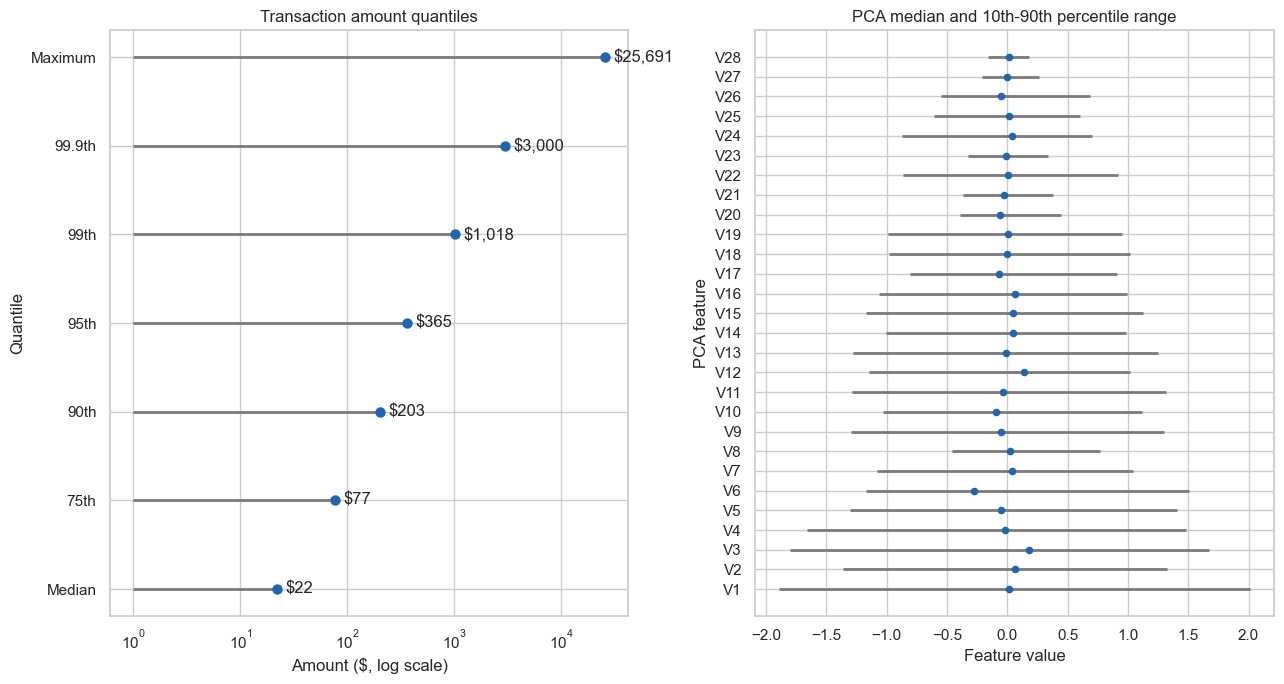

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
quantile_levels = [0.50, 0.75, 0.90, 0.95, 0.99, 0.999, 1.0]
quantile_labels = ["Median", "75th", "90th", "95th", "99th", "99.9th", "Maximum"]
amount_quantiles = df["Amount"].quantile(quantile_levels)
amount_quantiles.index = quantile_labels
print(
    f"Transaction Amount has a long upper tail: the median is ${amount_quantiles['Median']:,.2f}, "
    f"the 99th percentile is ${amount_quantiles['99th']:,.2f}, and the maximum is "
    f"${amount_quantiles['Maximum']:,.2f}."
)

feature_summary = df.loc[:, FEATURE_COLUMNS].describe().T[["mean", "std", "min", "50%", "max"]]

pca_columns = [f"V{i}" for i in range(1, 29)]
pca_ranges = df[pca_columns].quantile([0.10, 0.50, 0.90]).T
positions = np.arange(len(pca_columns))

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
amount_positions = np.arange(len(amount_quantiles))
axes[0].hlines(amount_positions, 1, amount_quantiles.values, color="#7A7A7A", linewidth=2)
axes[0].scatter(amount_quantiles.values, amount_positions, color="#2166AC", s=42, zorder=2)
for position, value in zip(amount_positions, amount_quantiles.values):
    axes[0].annotate(f"${value:,.0f}", (value, position), xytext=(6, 0), textcoords="offset points", va="center")
axes[0].set_yticks(amount_positions, amount_quantiles.index)
axes[0].set_xscale("log")
axes[0].set_title("Transaction amount quantiles")
axes[0].set_xlabel("Amount ($, log scale)")
axes[0].set_ylabel("Quantile")

axes[1].hlines(positions, pca_ranges[0.10], pca_ranges[0.90], color="#7A7A7A", linewidth=2)
axes[1].scatter(pca_ranges[0.50], positions, color="#2166AC", s=20, zorder=2)
axes[1].set_yticks(positions, pca_columns)
axes[1].set_title("PCA median and 10th-90th percentile range")
axes[1].set_xlabel("Feature value")
axes[1].set_ylabel("PCA feature")
plt.tight_layout()
plt.show()

'Amount' in the dataset is strongly right-skewed, with most transactions being quite small (99% 1,018 or less) but a maximum transaction of $25,691. Additionally, while the PCA features are generally centered around zero, their ranges vary greatly. I therefore use RobustScaler to put features on comparable scales, particularly for the distance-based LOF model. This method prevents extreme values from inflating the scaling factor and diminishing the influence of unusually high-amount transactions

### Framing - Class imbalance/ Operational context

In [6]:
fraud_count = int(df["Class"].sum())
legitimate_count = int((df["Class"] == 0).sum())
fraud_rate = float(df["Class"].mean())

prevalence = pd.DataFrame({
    "metric": ["Legitimate transactions", "Fraud transactions", "Fraud prevalence"],
    "value": [f"{legitimate_count:,}", f"{fraud_count:,}", f"{fraud_rate:.4%}"],
})
display(prevalence)



,metric,value
0,Legitimate transactions,"284,315"
1,Fraud transactions,492
2,Fraud prevalence,0.1727%


Fraud in these transactions occurs at an extremely low rate: 0.1727 percent. Because of this severe class imbalance, a model predicting no fraud would be over 99% accurate, making standard accuracy a poor measurement of model performance. Instead I treat anomaly detection as a ranking problem, allowing analysts to focus on the riskiest anomaly scores. Because the organization currently reviews 5% of transactions, I use a 5% review rate as the primary operating point, maintaining the current analyst workload while evaluating whether automation can help identify more fraud. I also test slightly lower and higher review rates to examine the trade off between analyst workload and fraud detection. 

## 2. Approach and implementation

Due to the operational constraints and class imbalance described above, I use a ranking system to identify the riskiest transactions for analyst review. I use a common scoring architecture and evaluation framework to compare two anomaly detection models that each train without fraud labels and produce a continuous anomaly score. This allows transactions to be ranked from most to least anomalous, with analysts reviewing the highest-ranked transactions up to their available capacity. This is more useful operationally than relying on a fixed decision threshold. 

Isolation Forest is the primary model because it is unsupervised, computationally efficient, and effective at ranking unusual combinations of features. This notebook separates the development-only `train_anomaly_scorer` from the inference-only `FraudAnomalyScorer`. Production loads a packaged scoring artifact and calls the scoring methods, so another detector can be inserted without breaking downstream processes.

The anomaly detector is trained independently of analyst capacity and produces a continuous anomaly score. Analyst review capacity is applied downstream by ranking transactions and selecting the highest-scoring fraction for review. For evaluation, I use 5% as the primary operating point because it approximates the current review workload.

## 2.1 Models Tested

I tested two unsupervised anomaly detection models: Isolation Forest and Local Outlier Factor (LOF). Both produce continuous anomaly scores, which lets us rank transactions by risk and investigate the highest-scoring cases.

**Isolation Forest** identifies unusual observations by repeatedly partitioning the data and measuring how easily each observation can be isolated. It is also easier to use in production because new transactions can be scored directly without searching through a stored set of neighboring observations.

**Local Outlier Factor (LOF)** identifies transactions that are unusual relative to nearby observations. I tested several values for n_neighbors after increasing the development sample from 5,000 to 25,000 rows and selected 100 based on stable performance across the tested range. Unlike Isolation Forest, scoring new observations with LOF requires retaining the reference data.

Neither model uses fraud labels during training. I only use the known labels afterward to evaluate how well the anomaly scores rank actual fraud and to choose the LOF neighborhood size. Because I used the labels for those development decisions, I treat these results as model-development results rather than performance on a completely untouched final test set.



### Create development and test sets

This cell preserves transaction order in a 70/30 train-test split. Both candidate models use the same sampled development data and complete held-out test population in the comparison below. Fraud labels are not used for fitting.

In [7]:
# Preserve temporal order for evaluation. Labels are not used for fitting.
train_fraction = 0.70
split_idx = int(len(df) * train_fraction)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"Development rows: {len(train_df):,}")
print(f"Held-out test rows: {len(test_df):,}")

Development rows: 199,364
Held-out test rows: 85,443


## 3. Evaluation at operating points

Accuracy is not useful here because the non-fraud class dominates. Instead, I evaluate at fixed review rates:

- How many transactions are sent to analysts?
- How many fraud cases are captured?
- What is precision among reviewed cases?
- How many false positives occur per true positive?

This maps model performance directly to analyst workload.

The next cells calculate and plot precision and recall for both approaches across review budgets. They also include the analyst baseline from the assignment: the current rule system reviews about 5% of transactions and analysts estimate roughly 90% of those are false positives, so the baseline precision is about 10%.

### Compare models across analyst review budgets

This cell fits both candidate models through the common scoring interface using the same 25,000-row training sample and evaluates their rankings on the full held-out test population. It compares fraud precision and recall across review budgets, then reports fit time, scoring throughput, and serialized artifact size on local hardware. Note: These tests are for demonstration purposes and are not expected to completely recreate production conditions. 

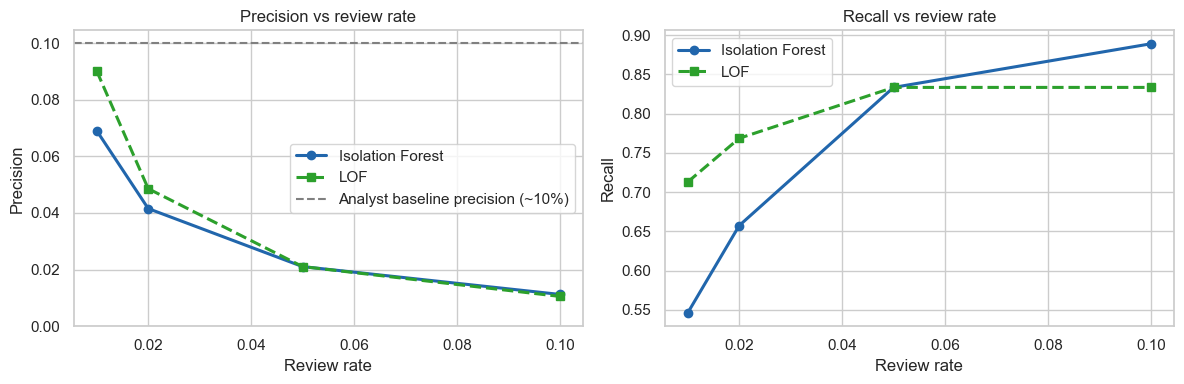

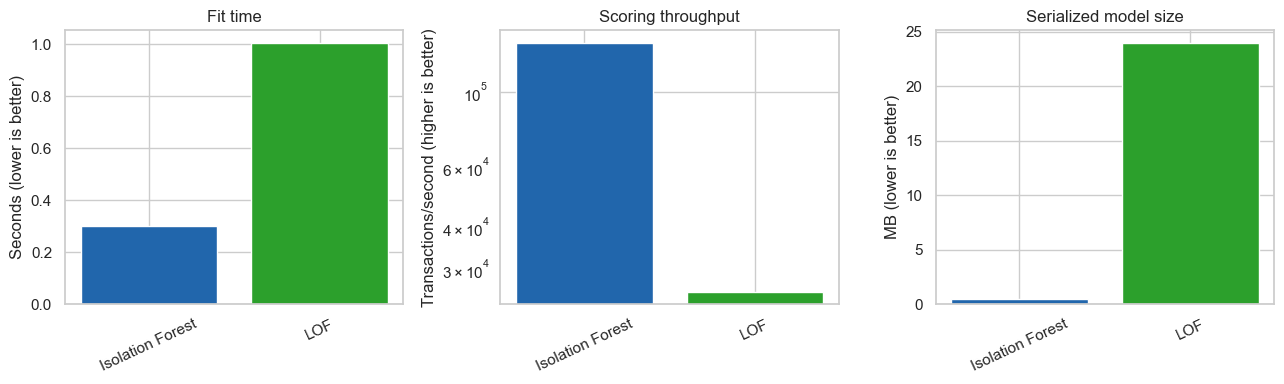

In [8]:
# Compare every model through the same fit-and-score interface.
review_rates = [0.01, 0.02, 0.05, 0.10]
comparison_train_size = 25000
comparison_test_df = test_df.copy()
train_sample = train_df.sample(n=min(comparison_train_size, len(train_df)), random_state=RANDOM_STATE)

model_configs = {
    "Isolation Forest": {"model_name": "isolation_forest", "model_params": {"n_estimators": 200}},
    "LOF": {"model_name": "local_outlier_factor", "model_params": {"n_neighbors": 100}},
}

import io
import time

import joblib

candidate_scorers = {}
metric_frames = []
benchmark_rows = []
for display_name, config in model_configs.items():
    fit_started = time.perf_counter()
    candidate = train_anomaly_scorer(train_sample, **config)
    fit_seconds = time.perf_counter() - fit_started
    candidate_scorers[display_name] = candidate

    score_started = time.perf_counter()
    candidate_scores = candidate.score_batch(comparison_test_df)
    score_seconds = time.perf_counter() - score_started
    candidate_eval = comparison_test_df[["Class"]].join(candidate_scores[["anomaly_score"]])
    model_metrics = pd.DataFrame(
        [evaluate_at_review_rate(candidate_eval, rate) for rate in review_rates]
    )
    model_metrics["model"] = display_name
    metric_frames.append(model_metrics)

    artifact_buffer = io.BytesIO()
    joblib.dump(candidate.to_bundle(), artifact_buffer, compress=3)
    benchmark_rows.append(
        {
            "model": display_name,
            "training_rows": len(train_sample),
            "scored_rows": len(comparison_test_df),
            "fit_seconds": fit_seconds,
            "score_seconds": score_seconds,
            "transactions_per_second": len(comparison_test_df) / score_seconds,
            "artifact_size_mb": len(artifact_buffer.getvalue()) / (1024 ** 2),
        }
    )

# Show the raw metrics to make the plots easier to interpret.
from IPython.display import display

comparison_metrics = pd.concat(metric_frames, ignore_index=True)
comparison_metrics = comparison_metrics[["model", "review_rate", "reviewed_transactions", "captured_fraud", "missed_fraud", "precision", "recall"]]
comparison_metrics.to_csv("model_comparison_metrics.csv", index=False)
# display(comparison_metrics.round(6))

operational_benchmarks = pd.DataFrame(benchmark_rows)
operational_benchmarks.to_csv("model_operational_benchmarks.csv", index=False)
# display(operational_benchmarks.round(4))

# Visual comparison of both approaches and the analyst baseline.
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

model_styles = {
    "Isolation Forest": {"color": "#2166AC", "marker": "o", "linestyle": "-"},
    "LOF": {"color": "#2CA02C", "marker": "s", "linestyle": "--"},
}

for model_name, style in model_styles.items():
    model_results = comparison_metrics.loc[comparison_metrics["model"] == model_name]
    axes[0].plot(
        model_results["review_rate"], model_results["precision"],
        linewidth=2.2, label=model_name, **style
    )
    axes[1].plot(
        model_results["review_rate"], model_results["recall"],
        linewidth=2.2, label=model_name, **style
    )
axes[0].axhline(0.10, color="gray", linestyle="--", label="Analyst baseline precision (~10%)")
axes[0].set_title("Precision vs review rate")
axes[0].set_xlabel("Review rate")
axes[0].set_ylabel("Precision")
axes[0].set_ylim(0, None)
axes[0].legend()

axes[1].set_title("Recall vs review rate")
axes[1].set_xlabel("Review rate")
axes[1].set_ylabel("Recall")
axes[1].legend()

plt.tight_layout()
plt.show()

benchmark_colors = [model_styles[name]["color"] for name in operational_benchmarks["model"]]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].bar(operational_benchmarks["model"], operational_benchmarks["fit_seconds"], color=benchmark_colors)
axes[0].set_title("Fit time")
axes[0].set_ylabel("Seconds (lower is better)")

axes[1].bar(operational_benchmarks["model"], operational_benchmarks["transactions_per_second"], color=benchmark_colors)
axes[1].set_title("Scoring throughput")
axes[1].set_ylabel("Transactions/second (higher is better)")
axes[1].set_yscale("log")

axes[2].bar(operational_benchmarks["model"], operational_benchmarks["artifact_size_mb"], color=benchmark_colors)
axes[2].set_title("Serialized model size")
axes[2].set_ylabel("MB (lower is better)")

for axis in axes:
    axis.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## 4. Productionization

Isolation Forest was selected as the best model for this application. Here I will train the final model on the full development dataset and save everything needed to score new transactions. I separate model training from production scoring so that new transactions use the same preprocessing and fitted model that were validated in development. 

### 4a. Inference interface

#### Build the production artifact



In [9]:
# DEVELOPMENT: fit the selected model on all development rows without labels.
scorer = train_anomaly_scorer(
    train_df,
    model_name="isolation_forest",
    random_state=RANDOM_STATE,
    model_params={"n_estimators": 200},
)
artifact_path = Path("fraud_scorer.joblib")
scorer.save(artifact_path)
print(f"Saved production artifact: {artifact_path}")

Saved production artifact: fraud_scorer.joblib


#### Final held-out review simulation

To illustrate how the anomaly ranking could be used operationally, I select the 5% of transactions with the highest anomaly scores. This matches the  review rate of the current process. Fraud labels are then used to evaluate how much known fraud this review queue would have captured.

,review_rate,reviewed_transactions,captured_fraud,missed_fraud,precision,recall
0,0.01,855,52,56,0.060819,0.481481
1,0.02,1709,68,40,0.039789,0.629630
2,0.05,4273,87,21,0.020360,0.805556
3,0.10,8545,93,15,0.010884,0.861111


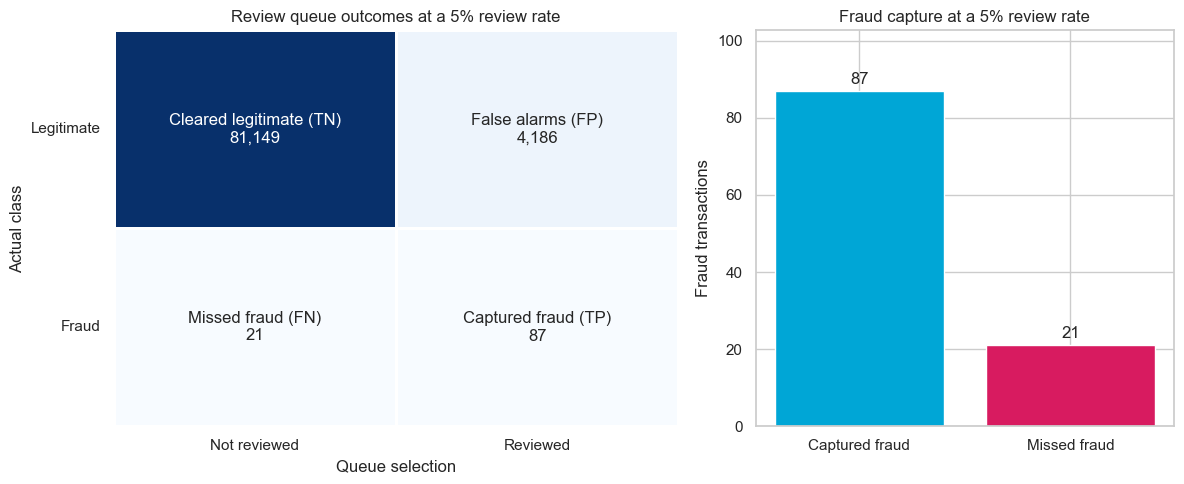

In [10]:
from sklearn.metrics import confusion_matrix

# Score the complete held-out population and evaluate fixed review budgets.
final_scores = scorer.score_batch(test_df)
final_eval = test_df[["Class"]].join(final_scores[["anomaly_score"]])
final_metrics = pd.DataFrame(
    [evaluate_at_review_rate(final_eval, rate) for rate in review_rates]
)
display(final_metrics[[
    "review_rate", "reviewed_transactions", "captured_fraud",
    "missed_fraud", "precision", "recall"
]].round(6))

selected_review_rate = 0.05
selected_threshold = final_eval["anomaly_score"].quantile(1 - selected_review_rate)
flagged_for_review = final_eval["anomaly_score"] >= selected_threshold
cm = confusion_matrix(final_eval["Class"], flagged_for_review, labels=[0, 1])

cell_labels = np.array([
    [f"Cleared legitimate (TN)\n{cm[0, 0]:,}", f"False alarms (FP)\n{cm[0, 1]:,}"],
    [f"Missed fraud (FN)\n{cm[1, 0]:,}", f"Captured fraud (TP)\n{cm[1, 1]:,}"],
])
fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1.35, 1]})
sns.heatmap(cm, annot=cell_labels, fmt="", cmap="Blues", cbar=False, linewidths=1, ax=axes[0])
axes[0].set_title("Review queue outcomes at a 5% review rate")
axes[0].set_xlabel("Queue selection")
axes[0].set_ylabel("Actual class")
axes[0].set_xticklabels(["Not reviewed", "Reviewed"])
axes[0].set_yticklabels(["Legitimate", "Fraud"], rotation=0)

fraud_outcomes = [cm[1, 1], cm[1, 0]]
bars = axes[1].bar(
    ["Captured fraud", "Missed fraud"], fraud_outcomes,
    color=["#00A6D6", "#D81B60"],
)
axes[1].bar_label(bars, labels=[f"{value:,}" for value in fraud_outcomes], padding=3)
axes[1].set_title("Fraud capture at a 5% review rate")
axes[1].set_ylabel("Fraud transactions")
axes[1].set_ylim(0, max(fraud_outcomes) * 1.18)
plt.tight_layout()
plt.show()

#### What is packaged

`fraud_scorer.joblib` is the artifact passed from development into production. It contains the fitted pipeline including `RobustScaler` and Isolation Forest, expected feature schema and order, and model version. Production should not recreate the scaler or model independently because different preprocessing would change the scores.

`FraudAnomalyScorer` provides the public inference methods. `score_batch` scores a DataFrame for ranking, while `score_one` handles one dictionary or Series through the same validation and scoring path.

#### Production inference

Everything above creates and validates the approved artifact. A production scoring process starts here: it loads `fraud_scorer.joblib`, validates new transactions, applies the already-fitted scaler and Isolation Forest, and returns anomaly scores. It never calls `.fit()`. Higher scores rank as riskier, and the model version is returned for traceability.

Transactions are scored as they arrive and held in an unreviewed queue for each client. As an initial operating plan, we could rank that queue hourly and send the highest-scoring transactions to analysts. For the current assignment, that rate is 5% of the window, but the figure could be adjusted over time based on model performance or analyst capacity. Queue selection is subsequent to scoring and not part of `FraudAnomalyScorer`.

In [11]:
# PRODUCTION INFERENCE: load fitted state; never train here.
production_scorer = FraudAnomalyScorer.load("fraud_scorer.joblib")

batch_input = test_df.head(10).loc[:, list(FEATURE_COLUMNS)]
batch_results = production_scorer.score_batch(batch_input)
single_result = production_scorer.score_one(batch_input.iloc[0])
print(f"Packaged fields: {sorted(production_scorer.to_bundle())}")
display(batch_results.head(3))
print(single_result)

Packaged fields: ['feature_columns', 'model_version', 'pipeline']


,anomaly_score,model_version
199364,0.408902,fraud-isolation_forest-v1
199365,0.420856,fraud-isolation_forest-v1
199366,0.428881,fraud-isolation_forest-v1


ScoreResult(anomaly_score=0.4089020374947329, model_version='fraud-isolation_forest-v1')


#### Input validation

Production rejects malformed transactions rather than silently returning an unreliable anomaly score. Before scoring, the input is verified to have all required features and finite, filled values. The tests below cover a missing required feature, NaN values, infinity, and the wrong batch input shape/type.

In [12]:
validation_cases = {
    "missing Amount": batch_input.drop(columns=["Amount"]),
    "NaN Amount": batch_input.assign(Amount=np.nan),
    "infinite Amount": batch_input.assign(Amount=np.inf),
    "wrong batch input type": batch_input.iloc[0],
}

validation_results = {}
for case_name, invalid_batch in validation_cases.items():
    try:
        production_scorer.score_batch(invalid_batch)
        raise AssertionError(f"{case_name} was unexpectedly scored")
    except (TypeError, ValueError) as error:
        validation_results[case_name] = str(error)

pd.Series(validation_results, name="expected validation error")

missing Amount                Missing required feature columns: ['Amount']
NaN Amount                Features must contain only finite numeric values
infinite Amount           Features must contain only finite numeric values
wrong batch input type             transactions must be a pandas DataFrame
Name: expected validation error, dtype: object

#### Serialization round-trip test

This test confirms that saving and reloading the model does not change its anomaly scores. 

In [13]:
before_reload = scorer.score_batch(batch_input)
reloaded_scorer = FraudAnomalyScorer.load(artifact_path)
after_reload = reloaded_scorer.score_batch(batch_input)
pd.testing.assert_frame_equal(before_reload, after_reload)
print("Serialization round-trip passed: scores are unchanged.")

Serialization round-trip passed: scores are unchanged.


### 4b. Operating the system

Once the model is in production, I would monitor incoming data and anomaly scores for changes from the data used to train the model. The basic tests of data quality mentioned above should generate alerts, but I would also monitor changes in feature and anomaly-score distributions, which could indicate either upstream data problems or that transaction behavior has changed. Changes between different clients would have to be examined to see whether adjustments are necessary to the model for their specific use cases. 

Fraud labels would likely be available after a delay, though I don't know how long that might be. As those results accumulate, I would calculate recall and precision at the analyst review rate, and compare with the performance of the deployed model during validation. A substantial decline in recall would be particularly important as it would indicate an increase in missed fraud. 

Drift in data or scoring would need to be investigated rather than triggering automatic retraining of the model. If the underlying data actually changed, I would train a new candidate model using more recent data and compare with the existing model at the same analyst review rate. The new model would replace the old model if it passes validation and production tests and performs better on the metrics we care about. 

Because transaction patterns may differ systematically across clients, I would not treat every difference from the global training distribution as model drift. I would establish a historical baseline for each client and compare changes both with that client's previous data and with changes occurring across other clients. If one client shows a large shift in a feature or anomaly-score distribution for several monitoring windows, while the other clients remain stable, I would investigate that client for an upstream data change or a need for client-specific model adjustments. If the same shift appears across many clients, it may instead reflect a broader change in transaction behavior which may or may not require action.

Each deployed model would be saved as a separate version rather than overwriting the previous artifact. If a new model causes problems after deployment, production could switch back to the previous version. 

### 4c. Scale and multi-tenancy

I would use the same scoring framework across clients, but I wouldn't assume that the model would work equally well for all clients. As discussed above, transaction data may differ systematically between clients. When enough historical data is available, I would evaluate whether a client-specific model improves fraud detection compared with the shared model. This may be guided by distribution checks showing that a feature in the base model has a different distribution for a particular client, indicating that the model may behave differently for them. Clients without much history could initially use the base model until enough data is available to determine whether tweaks are needed to the base model for that particular client. 

The percentage of transactions sent for review could also be set differently for each client based on transaction volume and analyst capacity, or if a particular client is seen to have a different baseline fraud rate. Client data, models, and scoring queues, etc should remain isolated so that a data-quality problem or model change for one client does not affect scoring of another. 

For deployment, Isolation Forest is my preferred production candidate. After limited tuning, LOF and Isolation Forest produced similar fraud-capture performance at the primary 5% review rate. I still prefer Isolation Forest because it has lower scoring and storage costs and should scale more effectively as transaction volume grows. LOF must retain the reference data and perform neighbor searches when scoring new transactions. These results support Isolation Forest for this dataset, although other models may still perform better, and could be easily swapped into this development pipeline. 

I would initially deploy Isolation Forest alongside the existing rule-based system and use it to prioritize the analyst review queue rather than automatically clearing or rejecting transactions. Because the assignment does not provide the existing rule system's fraud recall, I can't show whether my model actually outperforms it, although the approximately 80% recall at the 5% review rate suggests the model is identifying a substantial portion of the known fraud. I would first run both systems in parallel and compare performance at the same review rate before replacing the existing system or using the model to make automated decisions. Likely performance would have to improve greatly for that kind of automation. 